# Business Report Design Workflow

LangGraph-based workflow for generating enterprise-grade **Internal Business Report** HTML designs.

**Target Reports:** 주간업무보고, 기획안, 프로젝트 제안서, 결과 보고서, 회의록 등
**Input Source:** `report_generator.ipynb`에서 생성된 마크다운 콘텐츠

## Workflow Architecture

```
START
    │
    ▼
fetch_all_data (parallel HTTP GET x3)
    │
    ▼
prepare_sections
    │
    ▼
[fan_out] ──→ design_section (×N parallel)
    │              │
    │              ├─ render_template (Jinja2)
    │              ├─ call_llm (3-tier fallback)
    │              └─ extract_body_html
    │
    ▼ (fan-in via reducer)
combine_results
    │
    ▼
publish_report (PATCH)
    │
    ▼
END
```

## API Endpoints (Unchanged)
- `GET /customization/{report_id}` - Design requirements (colors, orientation)
- `GET /document-outlines/{report_id}` - Outline with sections
- `GET /reports/{report_id}` - Report metadata
- `PATCH /reports/{report_id}/publish-content` - Publish designed pages

## Cell 1: Imports & Configuration

In [1]:
# Standard library
import os
import re
import json
import asyncio
import operator
from pathlib import Path
from typing import TypedDict, Annotated, Optional, Literal
from dataclasses import dataclass, field

# Third-party
import httpx
from jinja2 import Environment, FileSystemLoader
from dotenv import load_dotenv

# LangChain & LangGraph
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

# Load environment variables
load_dotenv()

# Configuration
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
PROMPTS_DIR = Path(__file__).parent / "prompts" if "__file__" in dir() else Path("prompts")

print(f"Prompts directory: {PROMPTS_DIR}")
print(f"Google API Key configured: {bool(GOOGLE_API_KEY)}")

Prompts directory: prompts
Google API Key configured: True


## Cell 2: State Schema

In [2]:
# ============================================================
# State Schema Definitions for Internal Business Report Design
# ============================================================

class DesignRequirement(TypedDict):
    """Design customization for business reports from /customization endpoint.
    
    Used by: design_prompt.jinja2 template
    """
    primary_color: str      # e.g., "#1E40AF" - Main brand color
    secondary_color: str    # e.g., "#3B82F6" - Supporting color
    accent_color: str       # e.g., "#10B981" - Highlight/accent color
    pdf_orientation: str    # "portrait" | "landscape"


class Section(TypedDict):
    """A business report section to be designed.
    
    Fields aligned with design_prompt.jinja2 template requirements:
    - section_key: Special identifiers for layout decisions
    - parent_path: Breadcrumb navigation path
    - title: Section heading
    - content: Markdown/HTML content from report_generator
    """
    order: int                      # Sorting order
    section_title: str              # Display title
    section_number: Optional[str]   # e.g., "1.0", "2.1"
    section_key: str                # "EXECUTIVE_SUMMARY", "DATA_TABLE", etc.
    title: str                      # Main section title for header
    content: str                    # Markdown/HTML content
    parent_path: Optional[str]      # Breadcrumb path (e.g., "금주 업무 현황 > 성과 분석")


class DesignedPage(TypedDict):
    """Output from designing a single business report page."""
    html_content: str
    order: int
    section_title: str
    section_number: Optional[str]
    outline_id: str
    page_index: int              # For multi-page sections (content > 1200 chars)
    model_used: Optional[str]    # Track which LLM generated this


class ReportDesignState(TypedDict):
    """Main workflow state for business report design.
    
    Uses Annotated with operator.add for parallel aggregation of designed pages.
    """
    # API Inputs
    api_url: str
    token: str
    report_id: str
    
    # Fetched data from API
    design_requirement: Optional[DesignRequirement]
    outline: Optional[dict]
    report_metadata: Optional[dict]
    language_code: str
    sections: list[Section]
    
    # Parallel results - MUST use reducer for fan-in
    designed_pages: Annotated[list[DesignedPage], operator.add]
    
    # Final output
    publish_payload: Optional[str]
    
    # Metadata
    status: str
    errors: Annotated[list[str], operator.add]


class SectionPayload(TypedDict):
    """Payload sent to each parallel section processor via Send API."""
    section: Section
    design_requirement: DesignRequirement
    language_code: str
    outline_id: str


print("State schemas defined for Internal Business Reports!")
print("- DesignRequirement: colors + orientation")
print("- Section: order, title, content, section_key, parent_path")
print("- DesignedPage: html_content, order, model_used")

State schemas defined for Internal Business Reports!
- DesignRequirement: colors + orientation
- Section: order, title, content, section_key, parent_path
- DesignedPage: html_content, order, model_used


## Cell 3: LLM Configuration (3-tier Fallback)

In [3]:
# ============================================================
# LLM Configuration with 3-tier Fallback
# ============================================================

@dataclass
class LLMConfig:
    """LLM configuration for fallback chain."""
    name: str
    provider: str  # "google"
    temperature: float = 1.0
    max_retries: int = 3


# LLM configurations (3-tier fallback for reliability)
LLM_CONFIGS = [
    LLMConfig("gemini-2.0-flash", "google", 1.0),    # Primary
    LLMConfig("gemini-2.0-flash", "google", 1.0),    # Retry
    LLMConfig("gemini-1.5-pro", "google", 1.0),      # Fallback
]


def create_llm(config: LLMConfig) -> ChatGoogleGenerativeAI:
    """Factory function to create LLM based on config."""
    return ChatGoogleGenerativeAI(
        model=config.name,
        temperature=config.temperature,
        google_api_key=GOOGLE_API_KEY,
    )


def extract_text_content(content) -> str:
    """
    Extract text from LLM response content.
    Handles both string and list-based responses (Gemini format).
    """
    if isinstance(content, str):
        return content
    elif isinstance(content, list):
        texts = []
        for part in content:
            if isinstance(part, str):
                texts.append(part)
            elif hasattr(part, 'text'):
                texts.append(part.text)
            elif isinstance(part, dict) and 'text' in part:
                texts.append(part['text'])
        return ''.join(texts)
    return str(content)


async def call_llm_with_fallback(
    system_prompt: str,
    user_prompt: str,
    configs: list[LLMConfig] = LLM_CONFIGS
) -> tuple[str, str]:
    """
    Call LLM with 3-tier fallback chain.
    
    Returns:
        tuple[str, str]: (response_text, model_used)
    """
    for i, config in enumerate(configs):
        try:
            llm = create_llm(config)
            messages = [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ]
            response = await llm.ainvoke(messages)
            text = extract_text_content(response.content)
            
            # Check for empty response (triggers next in chain)
            if not text.strip() and i < len(configs) - 1:
                print(f"Empty response from {config.name}, trying next...")
                continue
            
            return text, config.name
            
        except Exception as e:
            print(f"LLM {config.name} failed: {e}")
            if i == len(configs) - 1:
                raise RuntimeError(f"All LLM attempts failed. Last error: {e}")
    
    raise RuntimeError("All LLM attempts failed")


print(f"LLM configs: {[c.name for c in LLM_CONFIGS]}")

LLM configs: ['gemini-2.0-flash', 'gemini-2.0-flash', 'gemini-1.5-pro']


## Cell 4: Template Loader

In [4]:
# ============================================================
# Jinja2 Prompt Loader for Business Report Design
# ============================================================

class PromptManager:
    """Manages Jinja2 prompt templates with caching."""
    
    def __init__(self, prompts_dir: Path):
        self.env = Environment(
            loader=FileSystemLoader(str(prompts_dir)),
            trim_blocks=True,
            lstrip_blocks=True,
        )
        self._prompt_cache = {}
    
    def get_prompt(self, name: str):
        """Get prompt template with caching."""
        if name not in self._prompt_cache:
            self._prompt_cache[name] = self.env.get_template(name)
        return self._prompt_cache[name]
    
    def render(self, prompt_name: str, **context) -> str:
        """Render prompt template with given context."""
        prompt = self.get_prompt(prompt_name)
        return prompt.render(**context)


# Initialize prompt manager
prompt_manager = PromptManager(PROMPTS_DIR)


def render_design_prompt(
    section: Section,
    design_requirement: DesignRequirement,
    content_length: int
) -> str:
    """
    Render the business report design prompt template.
    
    Template variables (from design_prompt.jinja2):
    - section: Section dict with title, content, section_key, parent_path
    - design_requirement: Colors and orientation
    - content_length: Character count for layout decisions
    
    The template includes:
    - Core rules (absolute constraints, required attributes)
    - Content metrics based on length
    - Design system (colors, typography)
    - Layout patterns for business reports
    - Infographic templates for KPIs, charts, etc.
    """
    return prompt_manager.render(
        "design_prompt.jinja2",
        section=section,
        design_requirement=design_requirement,
        content_length=content_length
    )


# Test prompt loading
try:
    test_prompt = prompt_manager.get_prompt("design_prompt.jinja2")
    print(f"Business report design prompt loaded successfully!")
except Exception as e:
    print(f"Prompt loading failed: {e}")

Prompt loading failed: 'design_prompt.jinja2' not found in search path: 'prompts'


## Cell 5: HTTP Fetch Nodes

In [5]:
# ============================================================
# HTTP Fetch Nodes (Parallel Data Fetching)
# API Endpoints preserved for backend compatibility
# ============================================================

async def fetch_all_data(state: ReportDesignState) -> dict:
    """
    Fetch all business report data in parallel.
    
    Endpoints (unchanged):
    - GET /customization/{report_id} - Design requirements
    - GET /document-outlines/{report_id} - Outline with sections
    - GET /reports/{report_id} - Report metadata
    """
    api_url = state["api_url"]
    token = state["token"]
    report_id = state["report_id"]
    
    headers = {"Authorization": f"Bearer {token}"}
    
    async with httpx.AsyncClient(timeout=30.0) as client:
        # Parallel fetch
        tasks = [
            client.get(f"{api_url}/customization/{report_id}", headers=headers),
            client.get(f"{api_url}/document-outlines/{report_id}", headers=headers),
            client.get(f"{api_url}/reports/{report_id}", headers=headers),
        ]
        
        responses = await asyncio.gather(*tasks, return_exceptions=True)
    
    # Process responses
    errors = []
    design_req = {}
    outline = {}
    report_meta = {}
    
    endpoint_names = ["customization", "document-outlines", "reports"]
    
    for i, resp in enumerate(responses):
        if isinstance(resp, Exception):
            errors.append(f"Fetch {endpoint_names[i]} failed: {str(resp)}")
            continue
        if resp.status_code != 200:
            errors.append(f"Fetch {endpoint_names[i]} returned {resp.status_code}")
            continue
        
        data = resp.json()
        if i == 0:
            design_req = data
        elif i == 1:
            outline = data
        else:
            report_meta = data
    
    # Extract language_code (default: Korean for business reports)
    language_code = report_meta.get("language_code", "ko")
    
    return {
        "design_requirement": design_req,
        "outline": outline,
        "report_metadata": report_meta,
        "language_code": language_code,
        "errors": errors,
        "status": "data_fetched"
    }


def prepare_sections(state: ReportDesignState) -> dict:
    """
    Extract business report sections array from outline.
    
    Sections should contain content from report_generator output.
    """
    outline = state.get("outline", {})
    sections = outline.get("sections", [])
    
    print(f"Prepared {len(sections)} sections for design")
    
    return {
        "sections": sections,
        "status": "sections_prepared"
    }


print("HTTP fetch nodes defined!")
print("Endpoints: /customization, /document-outlines, /reports")

HTTP fetch nodes defined!
Endpoints: /customization, /document-outlines, /reports


## Cell 6: Design Section Node (with LLM Fallback)

In [6]:
# ============================================================
# Design Section Node (Core Processing)
# For Internal Business Reports (주간업무보고, 기획안, etc.)
# ============================================================

# System prompt for the LLM - Business Report Designer
SYSTEM_PROMPT_TEMPLATE = """당신은 국내 주요 기업의 내부 비즈니스 보고서를 디자인해온 20년 경력의 시니어 문서 디자이너입니다.

당신의 특별한 능력:
- 콘텐츠를 읽고 정보의 본질적 구조를 파악
- 내용의 특성에 가장 적합한 레이아웃을 직관적으로 선택
- 복잡한 정보를 시각적으로 명료하게 재구성
- HTML/CSS만으로 전문적인 인포그래픽과 차트를 구현
- A4 페이지를 전문적이고 풍성하게 채우는 공간 활용의 전문가
- Flexbox/Grid 레이아웃의 달인 - 요소들이 절대 겹치지 않는 안정적 구조 설계
- {language_code} 언어로 주간업무보고, 기획안, 프로젝트 제안서, 결과 보고서, 회의록 등 비즈니스 문서를 디자인합니다.

당신은 Fortune 500대 기업들의 마케팅팀, 경영진, 프로젝트팀 등에서 의사결정을 위한 비즈니스 보고서를 디자인해왔습니다.

주요 비즈니스 보고서 유형:
- 주간업무보고: 핵심 성과 지표(KPI), 채널별 성과, 차주 계획
- 기획안: 배경, 목표, 실행 계획, 기대 효과
- 프로젝트 제안서: 현황 분석, 솔루션, 일정, 예산
- 결과 보고서: 성과 요약, 데이터 분석, 인사이트, 권고사항
- 회의록: 참석자, 논의사항, 결정사항, 액션아이템"""


def extract_body_blocks(
    html_content: str,
    section: Section,
    outline_id: str,
    model_used: Optional[str] = None
) -> list[DesignedPage]:
    """
    Extract all <body>...</body> blocks from LLM output.
    
    Handles multi-page sections (content > 1200 chars) that return multiple body blocks.
    Each body block becomes a separate page in the final report.
    """
    # Remove __PAGE_BREAK__ markers if any
    html_content = html_content.replace("__PAGE_BREAK__", "")
    
    # Find all body blocks
    body_pattern = r'<body[^>]*>.*?</body>'
    matches = re.findall(body_pattern, html_content, re.DOTALL | re.IGNORECASE)
    
    pages = []
    
    if matches:
        for idx, body_html in enumerate(matches):
            pages.append({
                "html_content": body_html,
                "order": section.get("order", 0),
                "section_title": section.get("section_title", ""),
                "section_number": section.get("section_number"),
                "outline_id": outline_id,
                "page_index": idx,
                "model_used": model_used
            })
    else:
        # No body tags found, use entire content
        pages.append({
            "html_content": html_content,
            "order": section.get("order", 0),
            "section_title": section.get("section_title", ""),
            "section_number": section.get("section_number"),
            "outline_id": outline_id,
            "page_index": 0,
            "model_used": model_used
        })
    
    return pages


async def design_section(state: SectionPayload) -> dict:
    """
    Design a single business report section with 3-tier LLM fallback.
    
    This node is called in parallel via Send API.
    Combines: template rendering + LLM call + body extraction.
    
    Template handles:
    - Content length analysis (short/medium/long/multi-page)
    - Layout pattern selection (KPI dashboard, data analysis, etc.)
    - Multi-page splitting for content > 1200 chars
    """
    section = state["section"]
    design_req = state["design_requirement"]
    language_code = state["language_code"]
    outline_id = state["outline_id"]
    
    # Calculate content length for layout decisions
    content = section.get("content", "")
    content_length = len(content)
    
    print(f"Designing section: {section.get('section_title', 'Unknown')} ({content_length} chars)")
    
    try:
        # Render design prompt using Jinja2 template
        design_prompt = render_design_prompt(
            section=section,
            design_requirement=design_req,
            content_length=content_length
        )
        
        # Create system and user prompts
        system_prompt = SYSTEM_PROMPT_TEMPLATE.format(language_code=language_code)
        user_prompt = f"{design_prompt}\n\n{language_code} 언어를 사용하여 비즈니스 보고서 디자인을 시작하세요."
        
        # Call LLM with fallback
        html_content, model_used = await call_llm_with_fallback(
            system_prompt=system_prompt,
            user_prompt=user_prompt
        )
        
        # Extract <body> blocks (may be multiple for long content)
        pages = extract_body_blocks(
            html_content=html_content,
            section=section,
            outline_id=outline_id,
            model_used=model_used
        )
        
        print(f"Section '{section.get('section_title')}' completed: {len(pages)} page(s)")
        
        return {
            "designed_pages": pages,
            "errors": []
        }
        
    except Exception as e:
        error_msg = f"Section '{section.get('section_title', 'Unknown')}' failed: {str(e)}"
        print(f"ERROR: {error_msg}")
        return {
            "designed_pages": [],
            "errors": [error_msg]
        }


print("Design section node defined for business reports!")

Design section node defined for business reports!


## Cell 7: Combine & Publish Nodes

In [7]:
# ============================================================
# Combine Results & Publish Nodes
# ============================================================

def combine_results(state: ReportDesignState) -> dict:
    """
    Flatten, sort, and re-index all designed pages.
    
    Sorting: by (order, page_index) to maintain section order
    and handle multi-page sections correctly.
    """
    pages = state.get("designed_pages", [])
    
    print(f"Combining {len(pages)} pages...")
    
    # Sort by (order, page_index)
    sorted_pages = sorted(
        pages,
        key=lambda x: (x.get("order", 0), x.get("page_index", 0))
    )
    
    # Re-assign order (1-based) and remove page_index
    final_pages = []
    for idx, page in enumerate(sorted_pages, start=1):
        final_pages.append({
            "html_content": page["html_content"],
            "order": idx,
            "section_title": page["section_title"],
            "section_number": page.get("section_number"),
            "outline_id": page["outline_id"]
        })
    
    # Create payload for API
    payload = {"publish_content": final_pages}
    
    print(f"Combined {len(final_pages)} pages for publishing")
    
    return {
        "publish_payload": json.dumps(payload, ensure_ascii=False),
        "status": "combined"
    }


async def publish_report(state: ReportDesignState) -> dict:
    """
    PATCH the publish_content to the API.
    
    Endpoint (unchanged): PATCH /reports/{report_id}/publish-content
    """
    api_url = state["api_url"]
    token = state["token"]
    report_id = state["report_id"]
    payload = state.get("publish_payload", "{}")
    
    print(f"Publishing business report {report_id}...")
    
    async with httpx.AsyncClient(timeout=60.0) as client:
        response = await client.patch(
            f"{api_url}/reports/{report_id}/publish-content",
            headers={
                "Authorization": f"Bearer {token}",
                "Content-Type": "application/json"
            },
            content=payload
        )
    
    if response.status_code not in (200, 201, 204):
        error_msg = f"Publish failed: {response.status_code} - {response.text[:200]}"
        print(f"ERROR: {error_msg}")
        return {
            "errors": [error_msg],
            "status": "publish_failed"
        }
    
    print("Business report published successfully!")
    return {"status": "completed"}


print("Combine and publish nodes defined!")

Combine and publish nodes defined!


## Cell 8: Graph Construction (StateGraph + Send API)

In [8]:
# ============================================================
# Graph Construction with Fan-out/Fan-in Pattern
# ============================================================

def fan_out_to_sections(state: ReportDesignState) -> list[Send]:
    """
    Distribute sections to parallel design workers.
    
    Returns list of Send objects, one per section.
    Supports up to 20+ parallel section designs.
    """
    sections = state.get("sections", [])
    design_req = state.get("design_requirement", {})
    language_code = state.get("language_code", "ko")
    outline = state.get("outline", {})
    outline_id = outline.get("id", "")
    
    print(f"Fanning out to {len(sections)} business report sections...")
    
    sends = []
    for section in sections:
        sends.append(
            Send(
                "design_section",
                {
                    "section": section,
                    "design_requirement": design_req,
                    "language_code": language_code,
                    "outline_id": outline_id
                }
            )
        )
    
    return sends


def build_report_design_graph():
    """
    Build the business report design workflow graph.
    
    Workflow:
        START -> fetch_all_data -> prepare_sections
              -> [fan_out] -> design_section (xN parallel)
              -> combine_results -> publish_report -> END
    """
    builder = StateGraph(ReportDesignState)
    
    # Add nodes
    builder.add_node("fetch_all_data", fetch_all_data)
    builder.add_node("prepare_sections", prepare_sections)
    builder.add_node("design_section", design_section)
    builder.add_node("combine_results", combine_results)
    builder.add_node("publish_report", publish_report)
    
    # Linear edges: START -> fetch -> prepare
    builder.add_edge(START, "fetch_all_data")
    builder.add_edge("fetch_all_data", "prepare_sections")
    
    # Fan-out edge: prepare -> [design_section x N]
    builder.add_conditional_edges(
        "prepare_sections",
        fan_out_to_sections,
        ["design_section"]
    )
    
    # Fan-in happens automatically due to reducer
    # Then: design_section -> combine -> publish -> END
    builder.add_edge("design_section", "combine_results")
    builder.add_edge("combine_results", "publish_report")
    builder.add_edge("publish_report", END)
    
    return builder.compile()


# Build the graph
report_design_graph = build_report_design_graph()
print("Business Report Design Graph built successfully!")

Business Report Design Graph built successfully!


## Cell 9: Graph Visualization

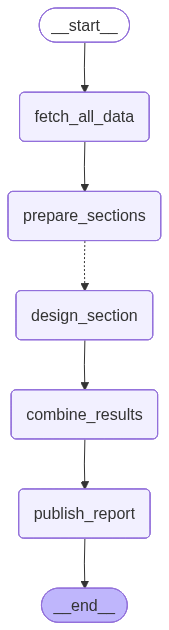

In [9]:
# ============================================================
# Graph Visualization
# ============================================================

try:
    from IPython.display import Image, display
    
    # Generate and display the graph
    graph_image = report_design_graph.get_graph().draw_mermaid_png()
    display(Image(graph_image))
except Exception as e:
    print(f"Graph visualization failed: {e}")
    print("\nGraph structure (Mermaid):")
    try:
        print(report_design_graph.get_graph().draw_mermaid())
    except:
        print("Could not generate Mermaid diagram")

## Cell 10: Execution

In [10]:
# ============================================================
# Workflow Execution
# ============================================================

async def run_report_design_workflow(
    api_url: str,
    token: str,
    report_id: str
) -> dict:
    """
    Execute the business report design workflow.
    
    Args:
        api_url: Base URL for the API (e.g., "https://api.example.com")
        token: Bearer authentication token
        report_id: Report identifier
    
    Returns:
        Final state with designed pages and status
    
    Example:
        result = await run_report_design_workflow(
            api_url="https://api.example.com",
            token="your_token_here",
            report_id="report-123"
        )
    """
    initial_state = {
        "api_url": api_url,
        "token": token,
        "report_id": report_id,
        "design_requirement": None,
        "outline": None,
        "report_metadata": None,
        "language_code": "ko",
        "sections": [],
        "designed_pages": [],
        "publish_payload": None,
        "status": "pending",
        "errors": []
    }
    
    print(f"Starting business report design workflow")
    print(f"Report ID: {report_id}")
    print("="*60)
    
    result = await report_design_graph.ainvoke(initial_state)
    
    print("="*60)
    print(f"Workflow completed with status: {result.get('status')}")
    print(f"Total pages designed: {len(result.get('designed_pages', []))}")
    if result.get('errors'):
        print(f"Errors: {result['errors']}")
    
    return result


# Example usage (uncomment to run)
# result = await run_report_design_workflow(
#     api_url="https://api.example.com",
#     token="your_token_here",
#     report_id="your_report_id_here"
# )

## Cell 11: Testing with Mock Data (Business Report)

In [11]:
# ============================================================
# Test with Mock Data - Business Report Content
# Based on report_generator.ipynb output format
# ============================================================

# Sample business report section (from report_generator output)
sample_section: Section = {
    "order": 1,
    "section_title": "금주 핵심 성과 요약",
    "section_number": "1.0",
    "section_key": "EXECUTIVE_SUMMARY",
    "title": "2024년 4분기 마케팅팀 주간업무보고",
    "content": """## 1. 금주 핵심 성과 요약 (Weekly Highlights)

본 섹션은 2024년 4분기 마케팅팀의 주간 주요 업무 성과를 기술합니다. 금주는 신규 캠페인의 본격적인 운영 단계로, 초기 트래픽 확보를 넘어 **실질적인 전환(Conversion)과 투자 대비 수익률(ROI)** 최적화에 주력했습니다.

### 1.1. 신규 캠페인 퍼포먼스 지표 (KPI) 달성 현황

금주 가장 괄목할 만한 성과는 신규 캠페인의 고객 반응률 급상승입니다.

*   **클릭률 (CTR) 대폭 상승:** 지난주 대비 **15% 상승**한 클릭률을 기록했습니다.
*   **목표 전환율 (CVR) 조기 달성:** 당초 4분기 중반 목표였던 **전환율 3.2%**를 금주에 조기 달성했습니다.

| 구분 | 지난주 (W-1) | **금주 (Current)** | 증감률 (WoW) |
| :--- | :---: | :---: | :---: |
| **클릭률 (CTR)** | 기준치 | **+15% 상승** | ▲ 15.0% |
| **전환율 (CVR)** | 2.8% | **3.2%** | ▲ 0.4%p |
| **ROAS** | 유지 | **상승** | ▲ 상승세 |

### 1.2. 채널별 ROI 최적화 및 예산 효율화

한정된 예산 내에서 최대의 성과를 내기 위해, 채널별 기여도 분석에 기반한 예산 재배치를 진행했습니다.

*   **저효율 지면 제외:** 클릭 당 비용(CPC)은 높으나 체류 시간이 짧은 3개 매체에 대한 송출을 중단
*   **고관여 타겟 집중:** 고효율 키워드 그룹에 예산을 20% 증액 편성하여 ROAS를 극대화""",
    "parent_path": "금주 업무 현황"
}

# Sample design requirement
sample_design_req: DesignRequirement = {
    "primary_color": "#1E40AF",
    "secondary_color": "#3B82F6",
    "accent_color": "#10B981",
    "pdf_orientation": "portrait"
}

# Test template rendering
print("Testing business report template rendering...")
try:
    test_prompt = render_design_prompt(
        section=sample_section,
        design_requirement=sample_design_req,
        content_length=len(sample_section["content"])
    )
    print(f"Template rendered successfully!")
    print(f"  - Content length: {len(sample_section['content'])} chars")
    print(f"  - Rendered prompt length: {len(test_prompt)} chars")
    print(f"\nFirst 800 chars of rendered prompt:")
    print("-" * 40)
    print(test_prompt[:800])
    print("-" * 40)
except Exception as e:
    print(f"Template rendering failed: {e}")

Testing business report template rendering...
Template rendering failed: 'design_prompt.jinja2' not found in search path: 'prompts'


In [12]:
# ============================================================
# Test: Long Content Multi-Page Section
# ============================================================

# Sample long content section (> 1200 chars triggers multi-page)
long_section: Section = {
    "order": 2,
    "section_title": "캠페인별 상세 성과 및 데이터 분석",
    "section_number": "2.0",
    "section_key": "DATA_ANALYSIS",
    "title": "캠페인별 상세 성과 및 데이터 분석",
    "content": """## 2. 캠페인별 상세 성과 및 데이터 분석

본 섹션에서는 2024년 4분기 주력 캠페인의 지난 주차(W4) 디지털 광고 성과를 정량적으로 분석하고, 채널별 예산 집행 대비 효율(ROI)을 점검합니다.

### 2.1. 디지털 광고 성과 추이 (Key Metrics Trend)

지난 주 실시한 신규 크리에이티브 A/B 테스트 및 타겟팅 최적화 작업의 결과로, 주요 성과 지표가 전주 대비 뚜렷한 상승세를 보였습니다.

*   **클릭률(CTR) 상승**: 직전 주차 대비 **15% 상승**하며 고객의 초기 반응률이 크게 개선되었습니다.
*   **전환율(CVR) 달성**: 목표치였던 3.0%를 상회하는 **3.2%의 전환율**을 달성했습니다.

| 구분 | 전주 대비 증감 | 금주 성과 | 비고 |
| :--- | :---: | :---: | :--- |
| **CTR** | ▲ 15% | **상승** | 신규 소재 반응 호조 |
| **CVR** | - | **3.2%** | 목표 초과 달성 |
| **CPA** | ▼ 감소 | **개선** | 효율 최적화 성공 |

### 2.2. 채널별 예산 집행 현황 및 ROI 비교

4분기 마케팅 예산 계획에 따라 주요 매체별로 예산을 집행하였으며, 성과 데이터에 기반하여 채널별 기여도를 평가했습니다.

*   **Meta (Instagram/Facebook)**: 신규 숏폼 영상 소재가 높은 인게이지먼트를 유도하며 가장 높은 ROI를 기록했습니다.
*   **Search Ads (SA)**: 브랜드 키워드 검색량은 안정적이나, 일반 키워드의 경쟁 심화로 CPC가 소폭 상승했습니다.

| 채널명 | 예산 집행률 | ROAS | 효율 등급 |
| :--- | :---: | :---: | :---: |
| **Meta** | 105% | **High** | **S** |
| **Google SA** | 100% | **High** | A |
| **Youtube** | 95% | Medium | B |
| **Network 배너** | 80% | Low | C |

### 2.3. 시사점 및 차주 최적화 전략

금주 데이터 분석을 통해 확인된 **'고효율 소재의 파급력'**과 **'타겟팅 정교화의 중요성'**을 바탕으로 차주 전략을 수립합니다.

1.  **Winning Creative 확장**: CTR 상승을 견인한 소재를 메인으로 교체
2.  **전환 중심의 예산 운용**: 전환율 3.5%까지 끌어올리기 위한 랜딩페이지 UI/UX 점검
3.  **저효율 채널 구조조정**: 네트워크 배너 광고 비중 10% 추가 축소""",
    "parent_path": "성과 분석 > 캠페인 상세"
}

print("Testing long content section (multi-page trigger)...")
print(f"Content length: {len(long_section['content'])} chars")
print(f"Expected pages: {max(1, -(-len(long_section['content']) // 1200))}")

try:
    long_prompt = render_design_prompt(
        section=long_section,
        design_requirement=sample_design_req,
        content_length=len(long_section["content"])
    )
    print(f"Long section template rendered successfully!")
    print(f"  - Rendered prompt length: {len(long_prompt)} chars")
    
    # Check if multi-page rules are included
    if "다중 페이지" in long_prompt or "페이지 분할" in long_prompt:
        print(f"  - Multi-page rules: Included")
    else:
        print(f"  - Multi-page rules: Not triggered (content may be under threshold)")
except Exception as e:
    print(f"Long section template failed: {e}")

Testing long content section (multi-page trigger)...
Content length: 1285 chars
Expected pages: 2
Long section template failed: 'design_prompt.jinja2' not found in search path: 'prompts'


In [13]:
# ============================================================
# Test LLM Call (Single Section - Optional)
# ============================================================

async def test_single_section_design():
    """Test designing a single business report section with the LLM."""
    if not GOOGLE_API_KEY:
        print("GOOGLE_API_KEY not set, skipping LLM test")
        return None
    
    print("Testing single section design with LLM...")
    print(f"Section: {sample_section['section_title']}")
    print(f"Content: {len(sample_section['content'])} chars")
    print("-" * 40)
    
    payload: SectionPayload = {
        "section": sample_section,
        "design_requirement": sample_design_req,
        "language_code": "ko",
        "outline_id": "test-outline-123"
    }
    
    result = await design_section(payload)
    
    if result.get("errors"):
        print(f"Errors: {result['errors']}")
        return result
    
    pages = result.get("designed_pages", [])
    print(f"\nDesign completed! Generated {len(pages)} page(s)")
    
    for i, page in enumerate(pages):
        print(f"\nPage {i+1}:")
        print(f"  - Model: {page.get('model_used')}")
        print(f"  - HTML length: {len(page.get('html_content', ''))} chars")
        html_preview = page.get('html_content', '')[:300]
        print(f"  - Preview: {html_preview}...")
    
    return result


# Uncomment to test (requires GOOGLE_API_KEY)
# result = await test_single_section_design()

## Cell 12: Complete Integration Test (Mock API)

In [14]:
# ============================================================
# Mock API Response Test
# Simulates backend API responses for end-to-end testing
# ============================================================

# Mock API responses matching expected backend format
mock_customization = {
    "primary_color": "#1E40AF",
    "secondary_color": "#3B82F6",
    "accent_color": "#10B981",
    "pdf_orientation": "portrait"
}

mock_outline = {
    "id": "outline-weekly-report-2024",
    "sections": [
        {
            "order": 1,
            "section_title": "금주 핵심 성과 요약",
            "section_number": "1",
            "section_key": "EXECUTIVE_SUMMARY",
            "title": "2024년 4분기 마케팅팀 주간업무보고",
            "content": sample_section["content"],
            "parent_path": "금주 업무 현황"
        },
        {
            "order": 2,
            "section_title": "캠페인별 상세 성과",
            "section_number": "2",
            "section_key": "DATA_ANALYSIS",
            "title": "캠페인별 상세 성과 및 데이터 분석",
            "content": long_section["content"],
            "parent_path": "성과 분석"
        },
        {
            "order": 3,
            "section_title": "차주 업무 계획",
            "section_number": "3",
            "section_key": "ACTION_PLAN",
            "title": "차주 업무 계획 및 이슈 사항",
            "content": """## 3. 차주 업무 계획 및 이슈 사항

### 3.1. 중점 추진 과제

*   **고효율 소재 예산 증액**: A/B안에 대해 일일 예산 20% 증액
*   **리타겟팅 강화**: 이탈 고객 대상 개인화 광고 집행
*   **신규 채널 테스트**: 틱톡/릴스 숏폼 플랫폼 시범 운영

### 3.2. 주간 업무 일정

| 요일 | 주요 업무 |
|:---|:---|
| 월 | 성과 데이터 분석 |
| 화 | 신규 소재 제작 |
| 수 | 광고 세팅 및 검수 |
| 목 | 초기 반응 모니터링 |
| 금 | 주간 성과 결산 |

### 3.3. 의사결정 필요 사항

**잔여 예산 재배정 승인 요청**: 검색광고 예산 500만원을 디스플레이 광고로 전용""",
            "parent_path": "차주 계획"
        }
    ]
}

mock_report_metadata = {
    "id": "report-2024-q4-week42",
    "title": "2024년 4분기 마케팅팀 주간업무보고",
    "language_code": "ko",
    "report_type": "주간업무보고",
    "company": "ABC 주식회사 마케팅팀"
}

print("Mock API data configured:")
print(f"  - Customization: {list(mock_customization.keys())}")
print(f"  - Outline sections: {len(mock_outline['sections'])}")
for s in mock_outline['sections']:
    print(f"    - {s['section_number']}. {s['section_title']} ({len(s['content'])} chars)")
print(f"  - Report metadata: {mock_report_metadata['title']}")

Mock API data configured:
  - Customization: ['primary_color', 'secondary_color', 'accent_color', 'pdf_orientation']
  - Outline sections: 3
    - 1. 금주 핵심 성과 요약 (805 chars)
    - 2. 캠페인별 상세 성과 (1285 chars)
    - 3. 차주 업무 계획 (368 chars)
  - Report metadata: 2024년 4분기 마케팅팀 주간업무보고


## Cell 13: Full Report Design Test with HTML Rendering

In [15]:
# ============================================================
# Full Report Design Test with HTML Rendering
# Designs all sections and displays the combined result
# ============================================================

from IPython.display import HTML, display

async def design_full_report_with_mock_data() -> dict:
    """
    Design the full business report using mock data.
    Bypasses API calls and directly processes all sections.
    
    Returns:
        dict with designed_pages and combined HTML
    """
    if not GOOGLE_API_KEY:
        print("GOOGLE_API_KEY not set, skipping full report test")
        return None
    
    print("=" * 60)
    print("FULL REPORT DESIGN TEST")
    print("=" * 60)
    print(f"Report: {mock_report_metadata['title']}")
    print(f"Sections: {len(mock_outline['sections'])}")
    print("=" * 60)
    
    all_pages = []
    errors = []
    
    # Design each section sequentially (for clearer output)
    # In production, these run in parallel via Send API
    for section in mock_outline["sections"]:
        print(f"\n▶ Designing: {section['section_number']}. {section['section_title']}")
        print(f"  Content: {len(section['content'])} chars")
        
        payload: SectionPayload = {
            "section": section,
            "design_requirement": mock_customization,
            "language_code": mock_report_metadata.get("language_code", "ko"),
            "outline_id": mock_outline["id"]
        }
        
        result = await design_section(payload)
        
        if result.get("errors"):
            errors.extend(result["errors"])
            print(f"  ✗ Error: {result['errors']}")
        else:
            pages = result.get("designed_pages", [])
            all_pages.extend(pages)
            print(f"  ✓ Generated {len(pages)} page(s)")
    
    print("\n" + "=" * 60)
    print(f"DESIGN COMPLETE: {len(all_pages)} total pages")
    if errors:
        print(f"Errors: {errors}")
    print("=" * 60)
    
    # Sort pages by order and page_index
    sorted_pages = sorted(
        all_pages,
        key=lambda x: (x.get("order", 0), x.get("page_index", 0))
    )
    
    return {
        "designed_pages": sorted_pages,
        "errors": errors,
        "report_metadata": mock_report_metadata
    }


def render_report_html(result: dict, show_page_breaks: bool = True) -> str:
    """
    Combine all designed pages into a single HTML document for rendering.
    
    Args:
        result: Output from design_full_report_with_mock_data()
        show_page_breaks: Add visual separators between pages
    
    Returns:
        Combined HTML string
    """
    if not result or not result.get("designed_pages"):
        return "<p>No pages to render</p>"
    
    pages = result["designed_pages"]
    metadata = result.get("report_metadata", {})
    
    # Build combined HTML
    html_parts = []
    
    # Report header
    html_parts.append(f"""
    <div style="background: linear-gradient(135deg, #1E40AF 0%, #3B82F6 100%); 
                color: white; padding: 20px; margin-bottom: 20px; border-radius: 8px;">
        <h1 style="margin: 0; font-size: 24px;">{metadata.get('title', 'Business Report')}</h1>
        <p style="margin: 5px 0 0 0; opacity: 0.9;">
            {metadata.get('company', '')} | {metadata.get('report_type', '')} | 
            Total Pages: {len(pages)}
        </p>
    </div>
    """)
    
    # Add each page
    for i, page in enumerate(pages):
        html_content = page.get("html_content", "")
        section_title = page.get("section_title", f"Page {i+1}")
        section_number = page.get("section_number", "")
        model_used = page.get("model_used", "unknown")
        
        # Page wrapper with metadata
        page_header = f"""
        <div style="background: #f8fafc; padding: 10px 15px; margin-bottom: 10px; 
                    border-left: 4px solid #3B82F6; border-radius: 4px;">
            <strong>Page {i+1}</strong> | {section_number}. {section_title} | 
            <span style="color: #6b7280; font-size: 12px;">Model: {model_used}</span>
        </div>
        """
        
        # Page content in a bordered container
        page_container = f"""
        <div style="border: 1px solid #e5e7eb; border-radius: 8px; 
                    margin-bottom: 30px; overflow: hidden; 
                    box-shadow: 0 1px 3px rgba(0,0,0,0.1);">
            {page_header}
            <div style="padding: 0;">
                {html_content}
            </div>
        </div>
        """
        
        html_parts.append(page_container)
        
        # Optional page break indicator
        if show_page_breaks and i < len(pages) - 1:
            html_parts.append("""
            <div style="text-align: center; color: #9ca3af; margin: 20px 0; 
                        border-top: 2px dashed #e5e7eb; padding-top: 10px;">
                ── Page Break ──
            </div>
            """)
    
    return "\n".join(html_parts)


print("Full report design functions defined!")
print("Run: result = await design_full_report_with_mock_data()")
print("Then: display(HTML(render_report_html(result)))")

Full report design functions defined!
Run: result = await design_full_report_with_mock_data()
Then: display(HTML(render_report_html(result)))


In [16]:
# ============================================================
# Execute Full Report Design and Render HTML
# ============================================================

# Run the full report design workflow
result = await design_full_report_with_mock_data()

# Display the rendered HTML report
if result and result.get("designed_pages"):
    print("\n🎨 Rendering HTML Report...\n")
    display(HTML(render_report_html(result)))
else:
    print("No pages were generated. Check GOOGLE_API_KEY configuration.")

FULL REPORT DESIGN TEST
Report: 2024년 4분기 마케팅팀 주간업무보고
Sections: 3

▶ Designing: 1. 금주 핵심 성과 요약
  Content: 805 chars
Designing section: 금주 핵심 성과 요약 (805 chars)
ERROR: Section '금주 핵심 성과 요약' failed: 'design_prompt.jinja2' not found in search path: 'prompts'
  ✗ Error: ["Section '금주 핵심 성과 요약' failed: 'design_prompt.jinja2' not found in search path: 'prompts'"]

▶ Designing: 2. 캠페인별 상세 성과
  Content: 1285 chars
Designing section: 캠페인별 상세 성과 (1285 chars)
ERROR: Section '캠페인별 상세 성과' failed: 'design_prompt.jinja2' not found in search path: 'prompts'
  ✗ Error: ["Section '캠페인별 상세 성과' failed: 'design_prompt.jinja2' not found in search path: 'prompts'"]

▶ Designing: 3. 차주 업무 계획
  Content: 368 chars
Designing section: 차주 업무 계획 (368 chars)
ERROR: Section '차주 업무 계획' failed: 'design_prompt.jinja2' not found in search path: 'prompts'
  ✗ Error: ["Section '차주 업무 계획' failed: 'design_prompt.jinja2' not found in search path: 'prompts'"]

DESIGN COMPLETE: 0 total pages
Errors: ["Section '금주 핵심 성과 요약' faile

## Cell 14: Individual Page Viewer & HTML Export

In [44]:
# ============================================================
# Individual Page Viewer & HTML Export Utilities
# ============================================================

def view_single_page(result: dict, page_index: int = 0) -> None:
    """
    Display a single page from the designed report.
    
    Args:
        result: Output from design_full_report_with_mock_data()
        page_index: 0-based index of the page to view
    """
    if not result or not result.get("designed_pages"):
        print("No pages available")
        return
    
    pages = result["designed_pages"]
    if page_index < 0 or page_index >= len(pages):
        print(f"Invalid page index. Available: 0-{len(pages)-1}")
        return
    
    page = pages[page_index]
    print(f"Page {page_index + 1}/{len(pages)}: {page.get('section_title')}")
    print(f"Model: {page.get('model_used')}")
    print(f"HTML length: {len(page.get('html_content', ''))} chars")
    print("-" * 40)
    
    display(HTML(page.get("html_content", "")))


def export_report_html(result: dict, filename: str = "designed_report.html") -> None:
    """
    Export the full designed report to an HTML file.
    
    Args:
        result: Output from design_full_report_with_mock_data()
        filename: Output filename
    """
    if not result or not result.get("designed_pages"):
        print("No pages to export")
        return
    
    pages = result["designed_pages"]
    metadata = result.get("report_metadata", {})
    
    # Build complete HTML document
    html_doc = f"""<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>{metadata.get('title', 'Business Report')}</title>
    <style>
        @page {{
            size: A4 portrait;
            margin: 0;
        }}
        body {{
            font-family: 'Pretendard', -apple-system, BlinkMacSystemFont, sans-serif;
            margin: 0;
            padding: 20px;
            background: #f5f5f5;
        }}
        .page-container {{
            background: white;
            margin: 20px auto;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
            max-width: 210mm;
        }}
        .page-header {{
            background: #f8fafc;
            padding: 10px 15px;
            border-bottom: 1px solid #e5e7eb;
            font-size: 12px;
            color: #6b7280;
        }}
        @media print {{
            body {{ background: white; padding: 0; }}
            .page-container {{ 
                box-shadow: none; 
                margin: 0;
                page-break-after: always;
            }}
            .page-header {{ display: none; }}
        }}
    </style>
</head>
<body>
    <h1 style="text-align: center; color: #1E40AF;">{metadata.get('title', 'Business Report')}</h1>
    <p style="text-align: center; color: #6b7280;">
        {metadata.get('company', '')} | Generated: {len(pages)} pages
    </p>
"""
    
    for i, page in enumerate(pages):
        html_doc += f"""
    <div class="page-container">
        <div class="page-header">
            Page {i+1} | {page.get('section_number', '')}. {page.get('section_title', '')}
        </div>
        {page.get('html_content', '')}
    </div>
"""
    
    html_doc += """
</body>
</html>
"""
    
    with open(filename, "w", encoding="utf-8") as f:
        f.write(html_doc)
    
    print(f"✓ Report exported to: {filename}")
    print(f"  - Pages: {len(pages)}")
    print(f"  - File size: {len(html_doc):,} bytes")


# Usage instructions
print("Individual page viewer and export utilities defined!")
print("")
print("View single page:")
print("  view_single_page(result, page_index=0)")
print("")
print("Export to HTML file:")
print("  export_report_html(result, 'my_report.html')")

Individual page viewer and export utilities defined!

View single page:
  view_single_page(result, page_index=0)

Export to HTML file:
  export_report_html(result, 'my_report.html')


In [ ]:
# ============================================================
# Example: View Individual Pages
# ============================================================

# View the first page (index 0)
if result and result.get("designed_pages"):
    print("Viewing first page only:\n")
    view_single_page(result, page_index=0)

In [45]:
# ============================================================
# Example: Export Full Report to HTML File
# ============================================================

# Export the full report to an HTML file
if result and result.get("designed_pages"):
    export_report_html(result, "designed_business_report.html")
    print("\nOpen the file in a browser to view the full report.")

✓ Report exported to: designed_business_report.html
  - Pages: 5
  - File size: 25,386 bytes

Open the file in a browser to view the full report.
